<a href="https://colab.research.google.com/github/sr606/Automated-3nf-data-modeling/blob/main/mermaid11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

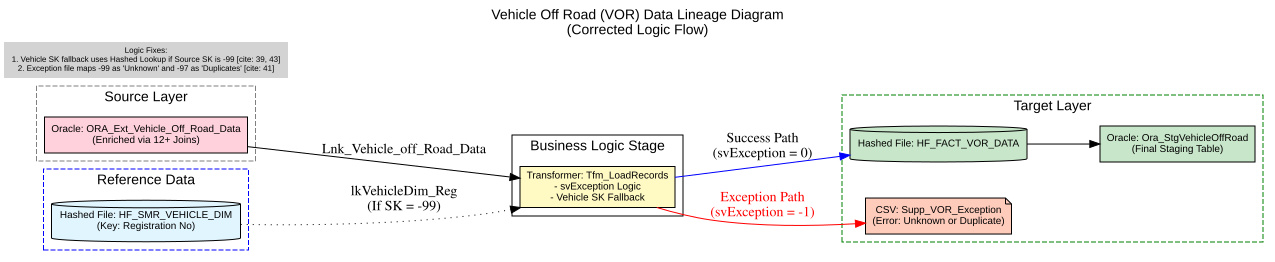

In [2]:
import graphviz

dot_code = '''
digraph G {
    // General Graph Settings
    rankdir=LR;
    nodesep=0.5;
    ranksep=1.0;
    fontname="Arial";
    label="Vehicle Off Road (VOR) Data Lineage Diagram\n(Corrected Logic Flow)";
    labelloc="t";

    // Node Styles
    node [shape=box, style="filled", fontname="Arial", fontsize=10];

    // Source Layer (Oracle)
    subgraph cluster_0 {
        label = "Source Layer";
        style = dashed;
        color = grey;
        Source_DB [label="Oracle: ORA_Ext_Vehicle_Off_Road_Data\n(Enriched via 12+ Joins)", fillcolor="#FFD1DC"];
    }

    // Lookup Layer
    subgraph cluster_1 {
        label = "Reference Data";
        style = dashed;
        color = blue;
        Lookup_Veh [label="Hashed File: HF_SMR_VEHICLE_DIM\n(Key: Registration No)", fillcolor="#E1F5FE", shape=cylinder];
    }

    // Transformation Layer
    subgraph cluster_2 {
        label = "Business Logic Stage";
        style = solid;
        Transformer [label="Transformer: Tfm_LoadRecords\n- svException Logic\n- Vehicle SK Fallback", fillcolor="#FFF9C4"];
    }

    // Output/Target Layer
    subgraph cluster_3 {
        label = "Target Layer";
        style = dashed;
        color = green;
        Hashed_Fact [label="Hashed File: HF_FACT_VOR_DATA", fillcolor="#C8E6C9", shape=cylinder];
        Target_DB [label="Oracle: Ora_StgVehicleOffRoad\n(Final Staging Table)", fillcolor="#C8E6C9"];
        Exception_File [label="CSV: Supp_VOR_Exception\n(Error: Unknown or Duplicate)", fillcolor="#FFCCBC", shape=note];
    }

    // Defined Edges (Lineage)
    Source_DB -> Transformer [label="Lnk_Vehicle_off_Road_Data"];

    // Lookup link
    Lookup_Veh -> Transformer [label="lkVehicleDim_Reg\n(If SK = -99)", style=dotted];

    // Branching Logic
    Transformer -> Hashed_Fact [label="Success Path\n(svException = 0)", color=blue];
    Hashed_Fact -> Target_DB;

    Transformer -> Exception_File [label="Exception Path\n(svException = -1)", color=red, fontcolor=red];

    // Footnote/Logic Notes
    Note1 [shape=plaintext, label="Logic Fixes:\n1. Vehicle SK fallback uses Hashed Lookup if Source SK is -99 [cite: 39, 43]\n2. Exception file maps -99 as 'Unknown' and -97 as 'Duplicates' [cite: 41]", fontsize=8];
}
'''

graphviz.Source(dot_code)

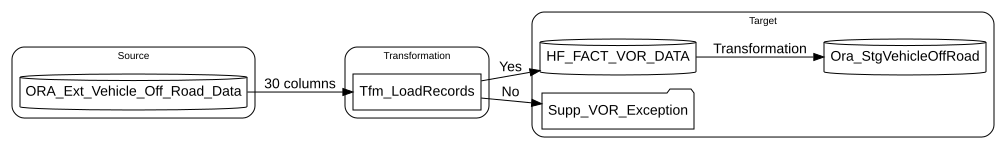

In [6]:
import graphviz

dot_code = '''
digraph Sample_Job1_1_2_detailed_pseudocode {
rankdir=LR;
fontsize=10;
fontname="Arial";
node [fontname="Arial"];
edge [fontname="Arial"];

subgraph cluster_source {
label="Source";
fontsize=10;
style=rounded;
Source_DB [label="ORA_Ext_Vehicle_Off_Road_Data", shape=cylinder];
}

subgraph cluster_processing {
label="Transformation";
fontsize=10;
style=rounded;
Transformer [label="Tfm_LoadRecords", shape=box];
}

subgraph cluster_target {
label="Target";
fontsize=10;
style=rounded;
Target_1 [label="HF_FACT_VOR_DATA", shape=cylinder];
Target_2 [label="Supp_VOR_Exception", shape=folder];
Target_3 [label="Ora_StgVehicleOffRoad", shape=cylinder];
}
Source_DB -> Transformer [label="30 columns"];
Transformer -> Target_1 [label="Yes"];
Transformer -> Target_2 [label="No"];
Target_1 -> Target_3 [label="Transformation"];
}
'''

graphviz.Source(dot_code)

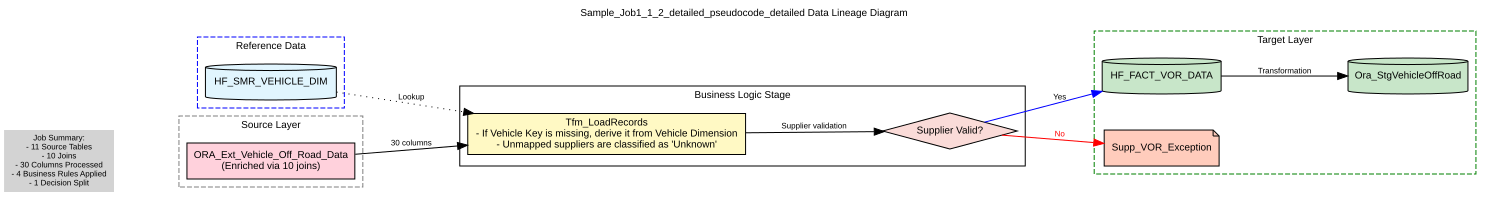

In [8]:
import graphviz

dot_code = '''
digraph Sample_Job1_1_2_detailed_pseudocode_detailed {
rankdir=LR;
nodesep=0.5;
ranksep=1.0;
fontname="Arial";
fontsize=10;
label="Sample_Job1_1_2_detailed_pseudocode_detailed Data Lineage Diagram";
labelloc="t";
node [shape=box, style="filled", fontname="Arial", fontsize=10];
edge [fontname="Arial", fontsize=8];

subgraph cluster_0 {
label="Source Layer";
style=dashed;
color=grey;
Source_DB [label="ORA_Ext_Vehicle_Off_Road_Data\n(Enriched via 10 joins)", fillcolor="#FFD1DC"];
}

subgraph cluster_1 {
label="Reference Data";
style=dashed;
color=blue;
Lookup_1 [label="HF_SMR_VEHICLE_DIM", fillcolor="#E1F5FE", shape=cylinder];
}

subgraph cluster_2 {
label="Business Logic Stage";
style=solid;
Transformer [label="Tfm_LoadRecords\n- If Vehicle Key is missing, derive it from Vehicle Dimension\n- Unmapped suppliers are classified as 'Unknown'", fillcolor="#FFF9C4"];
Decision [shape=diamond, label="Supplier Valid?", fillcolor="#FADBD8"];
}

subgraph cluster_3 {
label="Target Layer";
style=dashed;
color=green;
Target_1 [label="HF_FACT_VOR_DATA", fillcolor="#C8E6C9", shape=cylinder];
Target_2 [label="Supp_VOR_Exception", fillcolor="#FFCCBC", shape=note];
Target_3 [label="Ora_StgVehicleOffRoad", fillcolor="#C8E6C9", shape=cylinder];
}

Source_DB -> Transformer [label="30 columns"];
Lookup_1 -> Transformer [label="Lookup", style=dotted];
Transformer -> Decision [label="Supplier validation"];
Decision -> Target_1 [label="Yes", color=blue];
Decision -> Target_2 [label="No", color=red, fontcolor=red];
Target_1 -> Target_3 [label="Transformation"];
Note1 [shape=plaintext, label="Job Summary:\n- 11 Source Tables\n- 10 Joins\n- 30 Columns Processed\n- 4 Business Rules Applied\n- 1 Decision Split", fontsize=8];
Note1 -> Source_DB [style=invis];
}
'''

graphviz.Source(dot_code)

In [ ]:
📁 Project Structure
project/

data/
   upload/
   feature/

mcp/
   routes.py
   helpers.py
   drawio_mcp.py

agent/
   client.py
   lineage_agent.py
   server.py
1️⃣ mcp/helpers.py

Handles:

file reading

chunking

parsing pseudocode

building lineage

layout generation

import os
import re
from typing import List, Dict, Tuple
from pydantic import BaseModel

UPLOAD_DIR = "data/upload"
OUTPUT_DIR = "data/feature"


class ChunkRequest(BaseModel):
    file_name: str
    chunk_size: int = 2000
    overlap: int = 200


class ParseRequest(BaseModel):
    chunks: List[str]


class LineageGraph(BaseModel):
    nodes: List[str]
    edges: List[Tuple[str, str]]


class LayoutNode(BaseModel):
    id: str
    x: int
    y: int


class LayoutGraph(BaseModel):
    nodes: List[LayoutNode]
    edges: List[Tuple[str, str]]


# ---------------------------
# File utilities
# ---------------------------

def list_files() -> List[str]:
    return os.listdir(UPLOAD_DIR)


def read_file(file_name: str) -> str:
    path = os.path.join(UPLOAD_DIR, file_name)

    with open(path, "r") as f:
        return f.read()


# ---------------------------
# Chunking
# ---------------------------

def chunk_text(text: str, chunk_size: int = 2000, overlap: int = 200):

    chunks = []
    start = 0

    while start < len(text):

        end = start + chunk_size
        chunks.append(text[start:end])

        start = end - overlap

    return chunks


# ---------------------------
# Parsing pseudocode
# Example pattern:
# Stage: A
# Output: B
# ---------------------------

def parse_chunks(chunks: List[str]) -> LineageGraph:

    nodes = set()
    edges = []

    stage_pattern = r"Stage:\s*(\w+)"
    output_pattern = r"Output:\s*(\w+)"

    for chunk in chunks:

        stages = re.findall(stage_pattern, chunk)
        outputs = re.findall(output_pattern, chunk)

        for s in stages:
            nodes.add(s)

        for o in outputs:
            nodes.add(o)

        for i in range(min(len(stages), len(outputs))):
            edges.append((stages[i], outputs[i]))

    return LineageGraph(nodes=list(nodes), edges=edges)


# ---------------------------
# Layout generator
# simple left→right layout
# ---------------------------

def generate_layout(graph: LineageGraph) -> LayoutGraph:

    layout_nodes = []

    x = 100
    y = 100

    for node in graph.nodes:

        layout_nodes.append(
            LayoutNode(
                id=node,
                x=x,
                y=y
            )
        )

        y += 120

    return LayoutGraph(
        nodes=layout_nodes,
        edges=graph.edges
    )
2️⃣ mcp/drawio_mcp.py

Generates .drawio XML file.

import uuid
import os
from typing import Dict
from pydantic import BaseModel

OUTPUT_DIR = "data/feature"


class DrawIORequest(BaseModel):
    nodes: list
    edges: list
    file_name: str


def create_drawio_diagram(nodes, edges, file_name):

    node_ids = {}
    xml = []

    xml.append("<mxfile>")
    xml.append("<diagram>")
    xml.append("<mxGraphModel>")
    xml.append("<root>")
    xml.append('<mxCell id="0"/>')
    xml.append('<mxCell id="1" parent="0"/>')

    for node in nodes:

        node_id = str(uuid.uuid4())
        node_ids[node["id"]] = node_id

        cell = f"""
        <mxCell id="{node_id}" value="{node['id']}"
        style="rounded=1;whiteSpace=wrap;html=1;"
        vertex="1" parent="1">
        <mxGeometry x="{node['x']}" y="{node['y']}"
        width="140" height="60" as="geometry"/>
        </mxCell>
        """

        xml.append(cell)

    for src, dst in edges:

        edge_id = str(uuid.uuid4())

        edge = f"""
        <mxCell id="{edge_id}" edge="1" parent="1"
        source="{node_ids[src]}" target="{node_ids[dst]}">
        <mxGeometry relative="1" as="geometry"/>
        </mxCell>
        """

        xml.append(edge)

    xml.append("</root>")
    xml.append("</mxGraphModel>")
    xml.append("</diagram>")
    xml.append("</mxfile>")

    output_path = os.path.join(OUTPUT_DIR, file_name)

    with open(output_path, "w") as f:
        f.write("\n".join(xml))

    return output_path
3️⃣ mcp/routes.py

All MCP routes in one place.

import os
from fastapi import APIRouter
from pydantic import BaseModel

from .helpers import (
    list_files,
    read_file,
    chunk_text,
    parse_chunks,
    generate_layout,
)

from .drawio_mcp import create_drawio_diagram


router = APIRouter()

log_path = os.environ.get("BASE_LOG_PATH")


class FileRequest(BaseModel):
    file_name: str


class ChunkRequest(BaseModel):
    file_name: str
    chunk_size: int = 2000
    overlap: int = 200


class ParseRequest(BaseModel):
    chunks: list


class DrawRequest(BaseModel):
    nodes: list
    edges: list
    file_name: str


# ----------------------
# File operations
# ----------------------

@router.get("/files")
def get_files():
    return {"files": list_files()}


@router.post("/read-file")
def read_pseudo_file(req: FileRequest):

    content = read_file(req.file_name)

    return {"content": content}


# ----------------------
# Chunking
# ----------------------

@router.post("/chunk")
def chunk_file(req: ChunkRequest):

    content = read_file(req.file_name)

    chunks = chunk_text(content, req.chunk_size, req.overlap)

    return {"chunks": chunks}


# ----------------------
# Parsing
# ----------------------

@router.post("/parse")
def parse(req: ParseRequest):

    graph = parse_chunks(req.chunks)

    return graph


# ----------------------
# Layout
# ----------------------

@router.post("/layout")
def layout(graph):

    layout_graph = generate_layout(graph)

    return layout_graph


# ----------------------
# draw.io diagram
# ----------------------

@router.post("/drawio")
def drawio(req: DrawRequest):

    path = create_drawio_diagram(
        req.nodes,
        req.edges,
        req.file_name
    )

    return {"diagram": path}
4️⃣ agent/server.py

FastAPI app.

from fastapi import FastAPI
from mcp.routes import router

app = FastAPI()

app.include_router(router, prefix="/mcp")


@app.get("/")
def health():
    return {"status": "running"}

Run server:

uvicorn agent.server:app --reload
5️⃣ agent/client.py

Simple streaming client placeholder.

import requests


BASE_URL = "http://localhost:8000/mcp"


def get_files():

    r = requests.get(f"{BASE_URL}/files")
    print(r.json())


if __name__ == "__main__":
    get_files()
6️⃣ Example Pseudocode Input

data/upload/job1.txt

Stage: OracleSource
Output: Transformer1

Stage: Transformer1
Output: Aggregator1

Stage: Aggregator1
Output: TargetTable
7️⃣ Test Flow

1️⃣ list files

GET /mcp/files

2️⃣ chunk file

POST /mcp/chunk

3️⃣ parse lineage

POST /mcp/parse

4️⃣ generate layout

POST /mcp/layout

5️⃣ create diagram

POST /mcp/drawio

Output:

data/feature/job1.drawio

Open this in draw.io → lineage diagram appears.

🚀 Next Step (when you ask)

Next we will integrate:

LangGraph agent

tool discovery from MCP

LLM parsing

chunk memory

automatic diagram generation

This will convert your project into a true lineage AI agent instead of just APIs.

now integrate
LangGraph agent
tool discovery from MCP
LLM parsing
chunk memory
automatic diagram generation

im using azure llm and also make requirements file and .env eample file tell mw what things will be needed for draw.io mcp

Below is a production-style integration of everything you asked for:

LangGraph agent

Tool discovery from MCP

Azure LLM parsing

Chunk memory

Automatic diagram generation

FastAPI server

requirements.txt

.env example

The flow becomes:

TXT pseudocode
      ↓
MCP tools
      ↓
LangGraph agent
      ↓
Chunk memory
      ↓
Azure LLM parsing
      ↓
Lineage graph
      ↓
Layout generator
      ↓
draw.io XML
      ↓
Automatic diagram

Your orchestration framework remains LangGraph and diagrams are generated for draw.io.

1️⃣ requirements.txt
fastapi
uvicorn
pydantic
python-dotenv

langchain
langchain-openai
langgraph

requests
tiktoken

networkx

Optional later:

graphviz
pygraphviz
2️⃣ .env.example
# Azure OpenAI
AZURE_OPENAI_API_KEY=
AZURE_OPENAI_ENDPOINT=
AZURE_OPENAI_DEPLOYMENT=gpt-4o
AZURE_OPENAI_API_VERSION=2024-02-15-preview

# logging
BASE_LOG_PATH=logs/

# data folders
UPLOAD_DIR=data/upload
OUTPUT_DIR=data/feature
3️⃣ Updated Architecture
data/
   upload/
   feature/

mcp/
   routes.py
   helpers.py
   drawio_mcp.py

agent/
   client.py
   lineage_agent.py
   server.py
4️⃣ LangGraph Agent (agent/lineage_agent.py)

This is the core AI brain.

import os
import requests
from dotenv import load_dotenv
from typing import TypedDict, List

from langgraph.graph import StateGraph, END
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage

load_dotenv()

BASE_URL = "http://localhost:8000/mcp"


# -------------------------
# State
# -------------------------

class AgentState(TypedDict):

    file_name: str
    chunks: List[str]
    parsed_chunks: List[dict]
    graph: dict
    layout: dict
    diagram: str


# -------------------------
# Azure LLM
# -------------------------

llm = AzureChatOpenAI(
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    temperature=0
)


# -------------------------
# MCP tool wrappers
# -------------------------

def read_chunks(state: AgentState):

    r = requests.post(
        f"{BASE_URL}/chunk",
        json={"file_name": state["file_name"]}
    )

    chunks = r.json()["chunks"]

    return {"chunks": chunks}


# -------------------------
# LLM Parsing
# -------------------------

def parse_with_llm(state: AgentState):

    parsed = []

    for chunk in state["chunks"]:

        prompt = f"""
Extract lineage information from the pseudocode.

Return JSON with:
nodes
edges

Pseudocode:
{chunk}
"""

        response = llm.invoke([HumanMessage(content=prompt)])

        parsed.append(response.content)

    return {"parsed_chunks": parsed}


# -------------------------
# Merge chunks (Chunk Memory)
# -------------------------

def merge_chunks(state: AgentState):

    nodes = set()
    edges = []

    for item in state["parsed_chunks"]:

        try:
            data = eval(item)

            nodes.update(data["nodes"])
            edges.extend(data["edges"])

        except:
            continue

    graph = {
        "nodes": list(nodes),
        "edges": edges
    }

    return {"graph": graph}


# -------------------------
# Layout generation
# -------------------------

def generate_layout(state: AgentState):

    r = requests.post(
        f"{BASE_URL}/layout",
        json=state["graph"]
    )

    layout = r.json()

    return {"layout": layout}


# -------------------------
# Create draw.io
# -------------------------

def create_diagram(state: AgentState):

    r = requests.post(
        f"{BASE_URL}/drawio",
        json={
            "nodes": state["layout"]["nodes"],
            "edges": state["layout"]["edges"],
            "file_name": "lineage.drawio"
        }
    )

    diagram = r.json()["diagram"]

    return {"diagram": diagram}


# -------------------------
# Graph Builder
# -------------------------

def build_agent():

    graph = StateGraph(AgentState)

    graph.add_node("read_chunks", read_chunks)
    graph.add_node("parse_llm", parse_with_llm)
    graph.add_node("merge", merge_chunks)
    graph.add_node("layout", generate_layout)
    graph.add_node("drawio", create_diagram)

    graph.set_entry_point("read_chunks")

    graph.add_edge("read_chunks", "parse_llm")
    graph.add_edge("parse_llm", "merge")
    graph.add_edge("merge", "layout")
    graph.add_edge("layout", "drawio")
    graph.add_edge("drawio", END)

    return graph.compile()


agent = build_agent()


# -------------------------
# Run agent
# -------------------------

def run_agent(file_name):

    result = agent.invoke(
        {
            "file_name": file_name,
            "chunks": [],
            "parsed_chunks": [],
            "graph": {},
            "layout": {},
            "diagram": ""
        }
    )

    return result
5️⃣ Client (agent/client.py)
from lineage_agent import run_agent

if __name__ == "__main__":

    result = run_agent("job1.txt")

    print(result["diagram"])
6️⃣ FastAPI Server (agent/server.py)
from fastapi import FastAPI
from mcp.routes import router
from agent.lineage_agent import run_agent

app = FastAPI()

app.include_router(router, prefix="/mcp")


@app.post("/run-agent")
def run(file_name: str):

    result = run_agent(file_name)

    return result

Run:

uvicorn agent.server:app --reload

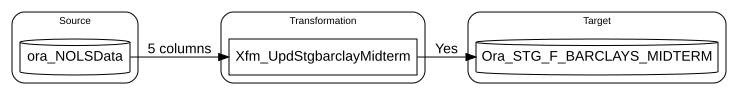

In [10]:
import graphviz

dot_code = '''
digraph LS_Sample_job1_1_2_detailed_pseudocode {
rankdir=LR;
fontsize=10;
fontname="Arial";
node [fontname="Arial"];
edge [fontname="Arial"];

subgraph cluster_source {
label="Source";
fontsize=10;
style=rounded;
Source_DB [label="ora_NOLSData", shape=cylinder];
}

subgraph cluster_processing {
label="Transformation";
fontsize=10;
style=rounded;
Transformer [label="Xfm_UpdStgbarclayMidterm", shape=box];
}

subgraph cluster_target {
label="Target";
fontsize=10;
style=rounded;
Target_1 [label="Ora_STG_F_BARCLAYS_MIDTERM", shape=cylinder];
}
Source_DB -> Transformer [label="5 columns"];
Transformer -> Target_1 [label="Yes"];
}
'''

graphviz.Source(dot_code)

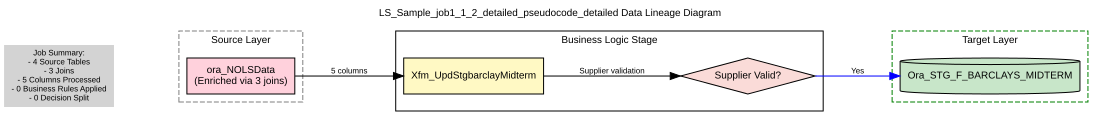

In [12]:
import graphviz

dot_code = '''
digraph LS_Sample_job1_1_2_detailed_pseudocode_detailed {
rankdir=LR;
nodesep=0.5;
ranksep=1.0;
fontname="Arial";
fontsize=10;
label="LS_Sample_job1_1_2_detailed_pseudocode_detailed Data Lineage Diagram";
labelloc="t";
node [shape=box, style="filled", fontname="Arial", fontsize=10];
edge [fontname="Arial", fontsize=8];

subgraph cluster_0 {
label="Source Layer";
style=dashed;
color=grey;
Source_DB [label="ora_NOLSData\n(Enriched via 3 joins)", fillcolor="#FFD1DC"];
}

subgraph cluster_1 {
label="Reference Data";
style=dashed;
color=blue;
}

subgraph cluster_2 {
label="Business Logic Stage";
style=solid;
Transformer [label="Xfm_UpdStgbarclayMidterm", fillcolor="#FFF9C4"];
Decision [shape=diamond, label="Supplier Valid?", fillcolor="#FADBD8"];
}

subgraph cluster_3 {
label="Target Layer";
style=dashed;
color=green;
Target_1 [label="Ora_STG_F_BARCLAYS_MIDTERM", fillcolor="#C8E6C9", shape=cylinder];
}

Source_DB -> Transformer [label="5 columns"];
Transformer -> Decision [label="Supplier validation"];
Decision -> Target_1 [label="Yes", color=blue];
Note1 [shape=plaintext, label="Job Summary:\n- 4 Source Tables\n- 3 Joins\n- 5 Columns Processed\n- 0 Business Rules Applied\n- 0 Decision Split", fontsize=8];
Note1 -> Source_DB [style=invis];
}
'''

graphviz.Source(dot_code)

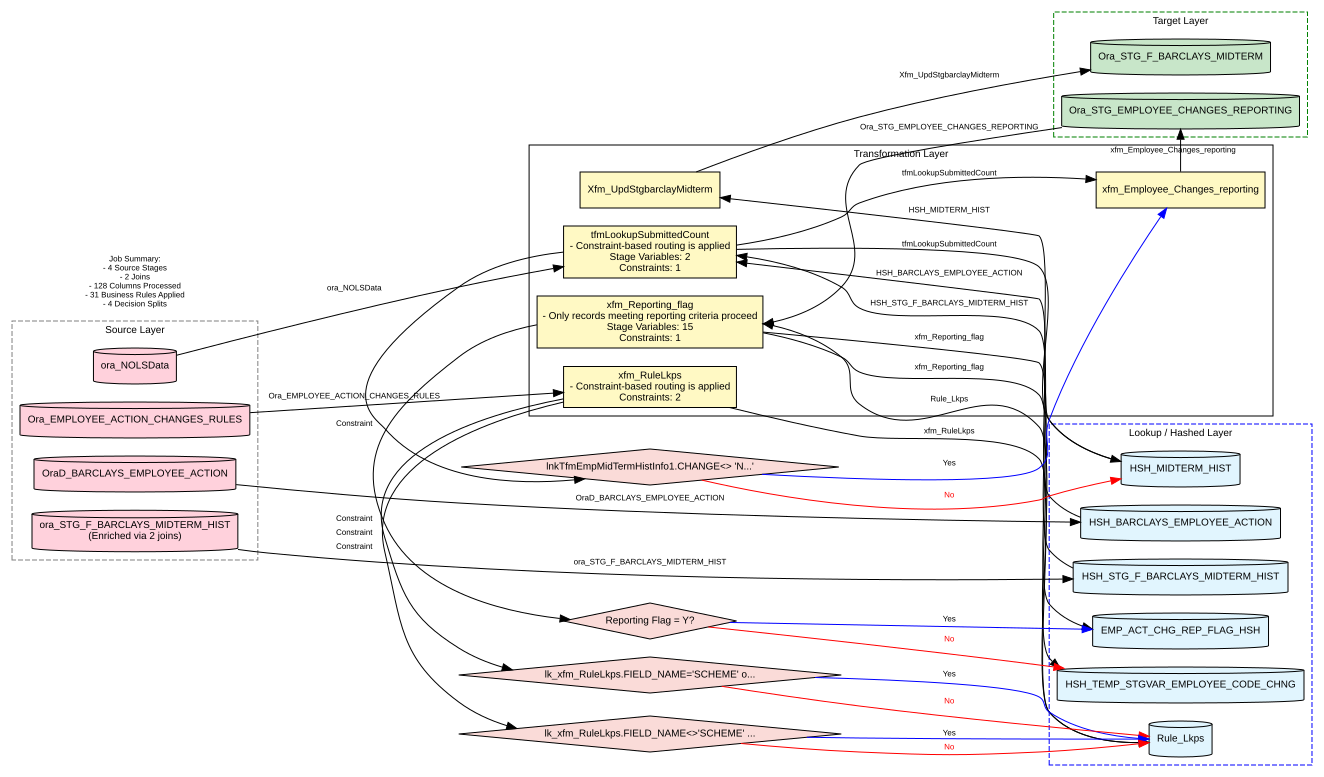

In [14]:
import graphviz

dot_code = '''
digraph LS_Sample_job1_1_2_detailed_pseudocode_detailed {
rankdir=LR;
fontsize=10;
fontname="Arial";
node [fontname="Arial", fontsize=10, style=filled];
edge [fontname="Arial", fontsize=8];

subgraph cluster_source {
label="Source Layer";
style=dashed;
color=grey;
ora_NOLSData [label="ora_NOLSData", shape=cylinder, fillcolor="#FFD1DC"];
OraD_BARCLAYS_EMPLOYEE_ACTION [label="OraD_BARCLAYS_EMPLOYEE_ACTION", shape=cylinder, fillcolor="#FFD1DC"];
ora_STG_F_BARCLAYS_MIDTERM_HIST [label="ora_STG_F_BARCLAYS_MIDTERM_HIST\n(Enriched via 2 joins)", shape=cylinder, fillcolor="#FFD1DC"];
Ora_EMPLOYEE_ACTION_CHANGES_RULES [label="Ora_EMPLOYEE_ACTION_CHANGES_RULES", shape=cylinder, fillcolor="#FFD1DC"];
}

subgraph cluster_lookup {
label="Lookup / Hashed Layer";
style=dashed;
color=blue;
HSH_MIDTERM_HIST [label="HSH_MIDTERM_HIST", shape=cylinder, fillcolor="#E1F5FE"];
HSH_BARCLAYS_EMPLOYEE_ACTION [label="HSH_BARCLAYS_EMPLOYEE_ACTION", shape=cylinder, fillcolor="#E1F5FE"];
HSH_STG_F_BARCLAYS_MIDTERM_HIST [label="HSH_STG_F_BARCLAYS_MIDTERM_HIST", shape=cylinder, fillcolor="#E1F5FE"];
EMP_ACT_CHG_REP_FLAG_HSH [label="EMP_ACT_CHG_REP_FLAG_HSH", shape=cylinder, fillcolor="#E1F5FE"];
Rule_Lkps [label="Rule_Lkps", shape=cylinder, fillcolor="#E1F5FE"];
HSH_TEMP_STGVAR_EMPLOYEE_CODE_CHNG [label="HSH_TEMP_STGVAR_EMPLOYEE_CODE_CHNG", shape=cylinder, fillcolor="#E1F5FE"];
}

subgraph cluster_transformation {
label="Transformation Layer";
style=solid;
color=black;
Xfm_UpdStgbarclayMidterm [label="Xfm_UpdStgbarclayMidterm", shape=box, fillcolor="#FFF9C4"];
xfm_Employee_Changes_reporting [label="xfm_Employee_Changes_reporting", shape=box, fillcolor="#FFF9C4"];
xfm_Reporting_flag [label="xfm_Reporting_flag\n- Only records meeting reporting criteria proceed\nStage Variables: 15\nConstraints: 1", shape=box, fillcolor="#FFF9C4"];
xfm_RuleLkps [label="xfm_RuleLkps\n- Constraint-based routing is applied\nConstraints: 2", shape=box, fillcolor="#FFF9C4"];
tfmLookupSubmittedCount [label="tfmLookupSubmittedCount\n- Constraint-based routing is applied\nStage Variables: 2\nConstraints: 1", shape=box, fillcolor="#FFF9C4"];
}

subgraph cluster_target {
label="Target Layer";
style=dashed;
color=green;
Ora_STG_F_BARCLAYS_MIDTERM [label="Ora_STG_F_BARCLAYS_MIDTERM", shape=cylinder, fillcolor="#C8E6C9"];
Ora_STG_EMPLOYEE_CHANGES_REPORTING [label="Ora_STG_EMPLOYEE_CHANGES_REPORTING", shape=cylinder, fillcolor="#C8E6C9"];
}
tfmLookupSubmittedCount -> HSH_MIDTERM_HIST [label="tfmLookupSubmittedCount"];
OraD_BARCLAYS_EMPLOYEE_ACTION -> HSH_BARCLAYS_EMPLOYEE_ACTION [label="OraD_BARCLAYS_EMPLOYEE_ACTION"];
ora_STG_F_BARCLAYS_MIDTERM_HIST -> HSH_STG_F_BARCLAYS_MIDTERM_HIST [label="ora_STG_F_BARCLAYS_MIDTERM_HIST"];
HSH_MIDTERM_HIST -> Xfm_UpdStgbarclayMidterm [label="HSH_MIDTERM_HIST"];
tfmLookupSubmittedCount -> xfm_Employee_Changes_reporting [label="tfmLookupSubmittedCount"];
Ora_STG_EMPLOYEE_CHANGES_REPORTING -> xfm_Reporting_flag [label="Ora_STG_EMPLOYEE_CHANGES_REPORTING"];
Rule_Lkps -> xfm_Reporting_flag [label="Rule_Lkps"];
xfm_Reporting_flag -> EMP_ACT_CHG_REP_FLAG_HSH [label="xfm_Reporting_flag"];
xfm_RuleLkps -> Rule_Lkps [label="xfm_RuleLkps"];
Ora_EMPLOYEE_ACTION_CHANGES_RULES -> xfm_RuleLkps [label="Ora_EMPLOYEE_ACTION_CHANGES_RULES"];
Xfm_UpdStgbarclayMidterm -> Ora_STG_F_BARCLAYS_MIDTERM [label="Xfm_UpdStgbarclayMidterm"];
xfm_Employee_Changes_reporting -> Ora_STG_EMPLOYEE_CHANGES_REPORTING [label="xfm_Employee_Changes_reporting"];
xfm_Reporting_flag -> HSH_TEMP_STGVAR_EMPLOYEE_CODE_CHNG [label="xfm_Reporting_flag"];
ora_NOLSData -> tfmLookupSubmittedCount [label="ora_NOLSData"];
HSH_BARCLAYS_EMPLOYEE_ACTION -> tfmLookupSubmittedCount [label="HSH_BARCLAYS_EMPLOYEE_ACTION"];
HSH_STG_F_BARCLAYS_MIDTERM_HIST -> tfmLookupSubmittedCount [label="HSH_STG_F_BARCLAYS_MIDTERM_HIST"];
xfm_Reporting_flag_decision_1 [shape=diamond, label="Reporting Flag = Y?", fillcolor="#FADBD8"];
xfm_Reporting_flag -> xfm_Reporting_flag_decision_1 [label="Constraint"];
xfm_Reporting_flag_decision_1 -> EMP_ACT_CHG_REP_FLAG_HSH [label="Yes", color=blue];
xfm_Reporting_flag_decision_1 -> HSH_TEMP_STGVAR_EMPLOYEE_CODE_CHNG [label="No", color=red, fontcolor=red];
xfm_RuleLkps_decision_1 [shape=diamond, label="lk_xfm_RuleLkps.FIELD_NAME='SCHEME' o...", fillcolor="#FADBD8"];
xfm_RuleLkps -> xfm_RuleLkps_decision_1 [label="Constraint"];
xfm_RuleLkps_decision_1 -> Rule_Lkps [label="Yes", color=blue];
xfm_RuleLkps_decision_1 -> Rule_Lkps [label="No", color=red, fontcolor=red];
xfm_RuleLkps_decision_2 [shape=diamond, label="lk_xfm_RuleLkps.FIELD_NAME<>'SCHEME' ...", fillcolor="#FADBD8"];
xfm_RuleLkps -> xfm_RuleLkps_decision_2 [label="Constraint"];
xfm_RuleLkps_decision_2 -> Rule_Lkps [label="Yes", color=blue];
xfm_RuleLkps_decision_2 -> Rule_Lkps [label="No", color=red, fontcolor=red];
tfmLookupSubmittedCount_decision_1 [shape=diamond, label="lnkTfmEmpMidTermHistInfo1.CHANGE<> 'N...'", fillcolor="#FADBD8"];
tfmLookupSubmittedCount -> tfmLookupSubmittedCount_decision_1 [label="Constraint"];
tfmLookupSubmittedCount_decision_1 -> xfm_Employee_Changes_reporting [label="Yes", color=blue];
tfmLookupSubmittedCount_decision_1 -> HSH_MIDTERM_HIST [label="No", color=red, fontcolor=red];
Note1 [shape=plaintext, label="Job Summary:\n- 4 Source Stages\n- 2 Joins\n- 128 Columns Processed\n- 31 Business Rules Applied\n- 4 Decision Splits", fontsize=8, fillcolor="white"];
}
'''

graphviz.Source(dot_code)

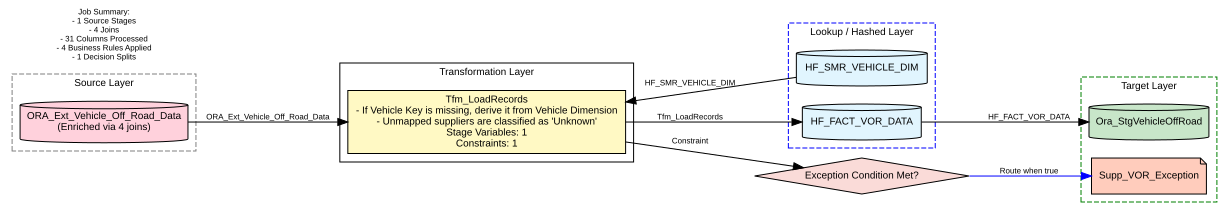

In [20]:
import graphviz

dot_code = '''
digraph Sample_Job1_1_2_detailed_pseudocode_detailed {
rankdir=LR;
fontsize=10;
fontname="Arial";
node [fontname="Arial", fontsize=10, style=filled];
edge [fontname="Arial", fontsize=8];

subgraph cluster_source {
label="Source Layer";
style=dashed;
color=grey;
ORA_Ext_Vehicle_Off_Road_Data [label="ORA_Ext_Vehicle_Off_Road_Data\n(Enriched via 4 joins)", shape=cylinder, fillcolor="#FFD1DC"];
}

subgraph cluster_lookup {
label="Lookup / Hashed Layer";
style=dashed;
color=blue;
HF_FACT_VOR_DATA [label="HF_FACT_VOR_DATA", shape=cylinder, fillcolor="#E1F5FE"];
HF_SMR_VEHICLE_DIM [label="HF_SMR_VEHICLE_DIM", shape=cylinder, fillcolor="#E1F5FE"];
}

subgraph cluster_transformation {
label="Transformation Layer";
style=solid;
color=black;
Tfm_LoadRecords [label="Tfm_LoadRecords\n- If Vehicle Key is missing, derive it from Vehicle Dimension\n- Unmapped suppliers are classified as 'Unknown'\nStage Variables: 1\nConstraints: 1", shape=box, fillcolor="#FFF9C4"];
}

subgraph cluster_target {
label="Target Layer";
style=dashed;
color=green;
Ora_StgVehicleOffRoad [label="Ora_StgVehicleOffRoad", shape=cylinder, fillcolor="#C8E6C9"];
Supp_VOR_Exception [label="Supp_VOR_Exception", shape=note, fillcolor="#FFCCBC"];
}
HF_FACT_VOR_DATA -> Ora_StgVehicleOffRoad [label="HF_FACT_VOR_DATA"];
Tfm_LoadRecords -> HF_FACT_VOR_DATA [label="Tfm_LoadRecords"];
ORA_Ext_Vehicle_Off_Road_Data -> Tfm_LoadRecords [label="ORA_Ext_Vehicle_Off_Road_Data"];
HF_SMR_VEHICLE_DIM -> Tfm_LoadRecords [label="HF_SMR_VEHICLE_DIM"];
Tfm_LoadRecords_decision_1 [shape=diamond, label="Exception Condition Met?", fillcolor="#FADBD8"];
Tfm_LoadRecords -> Tfm_LoadRecords_decision_1 [label="Constraint"];
Tfm_LoadRecords_decision_1 -> Supp_VOR_Exception [label="Route when true", color=blue];
Note1 [shape=plaintext, label="Job Summary:\n- 1 Source Stages\n- 4 Joins\n- 31 Columns Processed\n- 4 Business Rules Applied\n- 1 Decision Splits", fontsize=8, fillcolor="white"];
}
'''

graphviz.Source(dot_code)

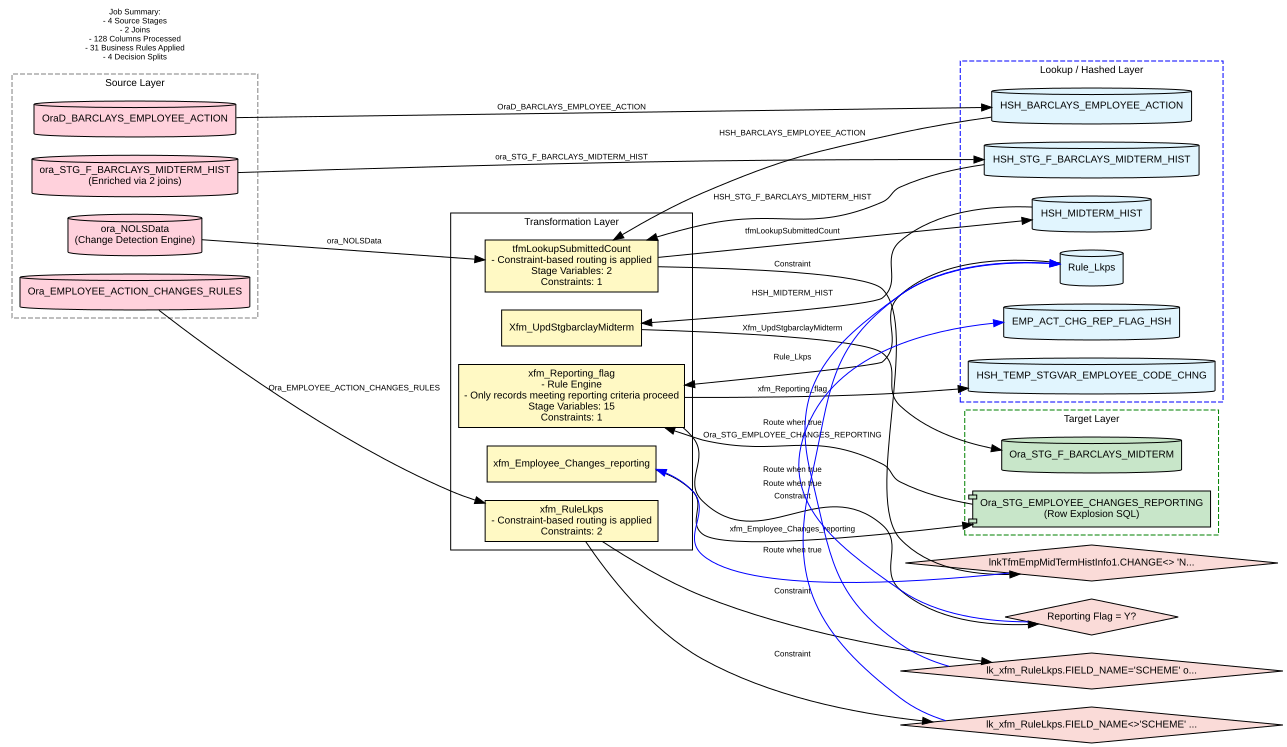

In [22]:
import graphviz

dot_code = '''
digraph LS_Sample_job1_1_2_detailed_pseudocode_detailed {
rankdir=LR;
fontsize=10;
fontname="Arial";
node [fontname="Arial", fontsize=10, style=filled];
edge [fontname="Arial", fontsize=8];

subgraph cluster_source {
label="Source Layer";
style=dashed;
color=grey;
ora_NOLSData [label="ora_NOLSData\n(Change Detection Engine)", shape=cylinder, fillcolor="#FFD1DC"];
OraD_BARCLAYS_EMPLOYEE_ACTION [label="OraD_BARCLAYS_EMPLOYEE_ACTION", shape=cylinder, fillcolor="#FFD1DC"];
ora_STG_F_BARCLAYS_MIDTERM_HIST [label="ora_STG_F_BARCLAYS_MIDTERM_HIST\n(Enriched via 2 joins)", shape=cylinder, fillcolor="#FFD1DC"];
Ora_EMPLOYEE_ACTION_CHANGES_RULES [label="Ora_EMPLOYEE_ACTION_CHANGES_RULES", shape=cylinder, fillcolor="#FFD1DC"];
}

subgraph cluster_lookup {
label="Lookup / Hashed Layer";
style=dashed;
color=blue;
HSH_MIDTERM_HIST [label="HSH_MIDTERM_HIST", shape=cylinder, fillcolor="#E1F5FE"];
HSH_BARCLAYS_EMPLOYEE_ACTION [label="HSH_BARCLAYS_EMPLOYEE_ACTION", shape=cylinder, fillcolor="#E1F5FE"];
HSH_STG_F_BARCLAYS_MIDTERM_HIST [label="HSH_STG_F_BARCLAYS_MIDTERM_HIST", shape=cylinder, fillcolor="#E1F5FE"];
EMP_ACT_CHG_REP_FLAG_HSH [label="EMP_ACT_CHG_REP_FLAG_HSH", shape=cylinder, fillcolor="#E1F5FE"];
Rule_Lkps [label="Rule_Lkps", shape=cylinder, fillcolor="#E1F5FE"];
HSH_TEMP_STGVAR_EMPLOYEE_CODE_CHNG [label="HSH_TEMP_STGVAR_EMPLOYEE_CODE_CHNG", shape=cylinder, fillcolor="#E1F5FE"];
}

subgraph cluster_transformation {
label="Transformation Layer";
style=solid;
color=black;
Xfm_UpdStgbarclayMidterm [label="Xfm_UpdStgbarclayMidterm", shape=box, fillcolor="#FFF9C4"];
xfm_Employee_Changes_reporting [label="xfm_Employee_Changes_reporting", shape=box, fillcolor="#FFF9C4"];
xfm_Reporting_flag [label="xfm_Reporting_flag\n- Rule Engine\n- Only records meeting reporting criteria proceed\nStage Variables: 15\nConstraints: 1", shape=box, fillcolor="#FFF9C4"];
xfm_RuleLkps [label="xfm_RuleLkps\n- Constraint-based routing is applied\nConstraints: 2", shape=box, fillcolor="#FFF9C4"];
tfmLookupSubmittedCount [label="tfmLookupSubmittedCount\n- Constraint-based routing is applied\nStage Variables: 2\nConstraints: 1", shape=box, fillcolor="#FFF9C4"];
}

subgraph cluster_target {
label="Target Layer";
style=dashed;
color=green;
Ora_STG_F_BARCLAYS_MIDTERM [label="Ora_STG_F_BARCLAYS_MIDTERM", shape=cylinder, fillcolor="#C8E6C9"];
Ora_STG_EMPLOYEE_CHANGES_REPORTING [label="Ora_STG_EMPLOYEE_CHANGES_REPORTING\n(Row Explosion SQL)", shape=component, fillcolor="#C8E6C9"];
}
tfmLookupSubmittedCount -> HSH_MIDTERM_HIST [label="tfmLookupSubmittedCount"];
OraD_BARCLAYS_EMPLOYEE_ACTION -> HSH_BARCLAYS_EMPLOYEE_ACTION [label="OraD_BARCLAYS_EMPLOYEE_ACTION"];
ora_STG_F_BARCLAYS_MIDTERM_HIST -> HSH_STG_F_BARCLAYS_MIDTERM_HIST [label="ora_STG_F_BARCLAYS_MIDTERM_HIST"];
HSH_MIDTERM_HIST -> Xfm_UpdStgbarclayMidterm [label="HSH_MIDTERM_HIST"];
Ora_STG_EMPLOYEE_CHANGES_REPORTING -> xfm_Reporting_flag [label="Ora_STG_EMPLOYEE_CHANGES_REPORTING"];
Rule_Lkps -> xfm_Reporting_flag [label="Rule_Lkps"];
Ora_EMPLOYEE_ACTION_CHANGES_RULES -> xfm_RuleLkps [label="Ora_EMPLOYEE_ACTION_CHANGES_RULES"];
Xfm_UpdStgbarclayMidterm -> Ora_STG_F_BARCLAYS_MIDTERM [label="Xfm_UpdStgbarclayMidterm"];
xfm_Employee_Changes_reporting -> Ora_STG_EMPLOYEE_CHANGES_REPORTING [label="xfm_Employee_Changes_reporting"];
xfm_Reporting_flag -> HSH_TEMP_STGVAR_EMPLOYEE_CODE_CHNG [label="xfm_Reporting_flag"];
ora_NOLSData -> tfmLookupSubmittedCount [label="ora_NOLSData"];
HSH_BARCLAYS_EMPLOYEE_ACTION -> tfmLookupSubmittedCount [label="HSH_BARCLAYS_EMPLOYEE_ACTION"];
HSH_STG_F_BARCLAYS_MIDTERM_HIST -> tfmLookupSubmittedCount [label="HSH_STG_F_BARCLAYS_MIDTERM_HIST"];
xfm_Reporting_flag_decision_1 [shape=diamond, label="Reporting Flag = Y?", fillcolor="#FADBD8"];
xfm_Reporting_flag -> xfm_Reporting_flag_decision_1 [label="Constraint"];
xfm_Reporting_flag_decision_1 -> EMP_ACT_CHG_REP_FLAG_HSH [label="Route when true", color=blue];
xfm_RuleLkps_decision_1 [shape=diamond, label="lk_xfm_RuleLkps.FIELD_NAME='SCHEME' o...", fillcolor="#FADBD8"];
xfm_RuleLkps -> xfm_RuleLkps_decision_1 [label="Constraint"];
xfm_RuleLkps_decision_1 -> Rule_Lkps [label="Route when true", color=blue];
xfm_RuleLkps_decision_2 [shape=diamond, label="lk_xfm_RuleLkps.FIELD_NAME<>'SCHEME' ...", fillcolor="#FADBD8"];
xfm_RuleLkps -> xfm_RuleLkps_decision_2 [label="Constraint"];
xfm_RuleLkps_decision_2 -> Rule_Lkps [label="Route when true", color=blue];
tfmLookupSubmittedCount_decision_1 [shape=diamond, label="lnkTfmEmpMidTermHistInfo1.CHANGE<> 'N...", fillcolor="#FADBD8"];
tfmLookupSubmittedCount -> tfmLookupSubmittedCount_decision_1 [label="Constraint"];
tfmLookupSubmittedCount_decision_1 -> xfm_Employee_Changes_reporting [label="Route when true", color=blue];
Note1 [shape=plaintext, label="Job Summary:\n- 4 Source Stages\n- 2 Joins\n- 128 Columns Processed\n- 31 Business Rules Applied\n- 4 Decision Splits", fontsize=8, fillcolor="white"];
}
'''

graphviz.Source(dot_code)